# Assignment 3: LLMs and Machine Learning

---

## Submission Instructions

Submit only a link to the folder for Assignment 3 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment3.ipynb` or something similar, placed inside the `assignments/assignment3/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Code Quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between tasks.
- Print out your answers so that the peer reviewer can see the results. Use the `df.head()` when asked to print the top  5 lines. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per task, and when reasonable, separate cells for subtasks.
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

## Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title

## Statement of use of AI

Include a brief statement describing how and which AI was used (or if no AI was used) in completing the assignment. This could be a markdown cell with a couple of sentences. As a reminder, AI use is permitted in the assignments, but it is advisable to try to complete the tasks as far as possible without and to make sure you understand the code that AI produced when using it.

## Grading

This assignment is worth 10 points. Task 0 is worth 1 point, and tasks 1-2 are worth 2 points and task 3 is worth 5 points.

Points are given only for code that runs. If the code does not run, the task (or subtask if code for a task is divided into multiple cells) will automatically receive 0 points even if the code is almost correct.

### Penalties

- **-2 points per task** where AI-generated (hallucinated) data is used instead of the actual data provided in the task or retrieved from the specified source. The assignment requires working with real data, not made-up values!
- **-3 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all tasks are completed within one cell, if answers are difficult to find due to too much irrelevant printed output).
- **-1 point** if there is no statement of AI use. If you did not use AI, report that you did not use AI.

### Editing the submission after the deadline

- Editing the assignment submission during the evaluation phase is forbidden. Thus, after the solution has been released, do not make any further changes to the notebook until you have received a grade. If you accidentally leaked an API key, revoke the key immediately. Other **changes to the submission are considered cheating, and will result in 0 points for both the assignment and peer review**.

---

## Tasks

### Task 0: Setting up Ollama (1p)

a) Set up Ollama and connect to it using either openAI's API or Ollama's own API. 

b) Load the 270m parameter version of the [gemma3](https://ollama.com/library/gemma3) model and test it with any prompt.

c) Load the 4b parameter version of the [gemma3](https://ollama.com/library/gemma3) and test it with any prompt. If running the 4b version is too slow, you can use the 1b version instead.

In [18]:
#a) The code for how i downloaded ollama
# ollama pull gemma3:270m
# ollama pull gemma3:4b

# and 
# ollama run gemma3:270m
# ollama run gemma3:4b

In [8]:
#b)
import requests

url = "http://localhost:11434/api/generate"

data = {
    "model": "gemma3:270m",
    "prompt": "Explain what Python is in one sentence.",
    "stream": False
}

response = requests.post(url, json=data)
result = response.json()

print(result["response"])

Python is a versatile, high-level programming language known for its readability, ease of use, and extensive libraries.



In [7]:
#c)
data = {
    "model": "gemma3:4b",
    "prompt": "Explain what machine learning is in one sentence.",
    "stream": False
}

response = requests.post(url, json=data)
result = response.json()

print(result["response"])

Machine learning is a field of computer science that allows systems to learn from data without being explicitly programmed, enabling them to improve their performance on a specific task over time.


### Task 1: Text classification with Ollama (2p)

The `data/emails.csv` file contains 12 email headlines, with 4 spam emails, 4 legitimate work emails and 4 vague emails that are hard to classify based on the title alone. Use this dataset for all subtasks in this task.

a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. The function should return only the classification and nothing else. (0.5p)

b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)

c) Use larger gemma3 (4b) to classify the emails using the function created in part a). In separate markdown cell, write a brief comment comparing the results of parts b) and c). (0.5p)

d) Write a script that repeats b) and c) 3 times, storing the results for both models separately. For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models. Comment if there were differences and explain why this happened. (0.5p)

In [44]:
#a)
import pandas as pd

emails = pd.read_csv("./assignments/Assignment1/emails.csv", on_bad_lines='skip')

print(emails.head())

                                            headline
0  URGENT: Your account will be suspended within ...
1  Hot singles in your area are waiting to meet y...
2  Re: Inheritance transfer of 4.5M USD pending y...
3       Meeting agenda for Thursday's project review
4  Reminder: Annual performance review scheduled ...


In [45]:
import requests

def classify_email(headline, model_name):
    
    url = "http://localhost:11434/api/generate"
    
    prompt = f"""
    Classify the following email headline as:
    spam
    work
    unknown

    Return ONLY one word:
    spam, work, or unknown

    Headline: {headline}
    """

    data = {
        "model": model_name,
        "prompt": prompt,
        "stream": False
    }

    response = requests.post(url, json=data)
    result = response.json()

    return result["response"].strip().lower()

In [67]:
#b)
emails["classification_270m"] = emails["headline"].apply(
    lambda x: classify_email(x, "gemma3:270m")
)

print(emails[["headline", "classification_270m"]])

                                            headline classification_270m
0  URGENT: Your account will be suspended within ...                spam
1  Hot singles in your area are waiting to meet y...                spam
2  Re: Inheritance transfer of 4.5M USD pending y...                spam
3       Meeting agenda for Thursday's project review               email
4  Reminder: Annual performance review scheduled ...                spam
5                     Quick question about last week                spam
6                                       Following up                    
7    Important update regarding your recent activity                spam
8                                 Are you available?         return only


In [66]:
#c) 
emails["classification_4b"] = emails["headline"].apply(
    lambda x: classify_email(x, "gemma3:4b")
)

print(emails[["headline", "classification_4b"]])

                                            headline classification_4b
0  URGENT: Your account will be suspended within ...              spam
1  Hot singles in your area are waiting to meet y...              spam
2  Re: Inheritance transfer of 4.5M USD pending y...              spam
3       Meeting agenda for Thursday's project review              work
4  Reminder: Annual performance review scheduled ...              work
5                     Quick question about last week           unknown
6                                       Following up              work
7    Important update regarding your recent activity              spam
8                                 Are you available?              spam


In [74]:
"The 4b model generally gave more consistent and accurate classifications than the 270m model. The smaller 270m model sometimes struggled with vague headlines and produced less reliable classifications, while the 4b model handled ambiguous cases better."

'The 4b model generally gave more consistent and accurate classifications than the 270m model. The smaller 270m model sometimes struggled with vague headlines and produced less reliable classifications, while the 4b model handled ambiguous cases better.'

In [49]:
#d)
results = pd.DataFrame()

results["headline"] = emails["headline"]

In [52]:
for i in range(1, 4):
    
    results[f"270m_run_{i}"] = emails["headline"].apply(
        lambda x: classify_email(x, "gemma3:270m")
    )

In [54]:
for i in range(1, 4):
    
    results[f"4b_run_{i}"] = emails["headline"].apply(
        lambda x: classify_email(x, "gemma3:4b")
    )

In [64]:
print(results)

                                            headline 4b_run_1 4b_run_2  \
0  URGENT: Your account will be suspended within ...     spam     spam   
1  Hot singles in your area are waiting to meet y...     spam     spam   
2  Re: Inheritance transfer of 4.5M USD pending y...     spam     spam   
3       Meeting agenda for Thursday's project review     work     work   
4  Reminder: Annual performance review scheduled ...     work     work   
5                     Quick question about last week  unknown  unknown   
6                                       Following up     work     work   
7    Important update regarding your recent activity     spam     spam   
8                                 Are you available?     spam     spam   

  4b_run_3        270m_run_1 270m_run_2 270m_run_3  
0     spam              spam       spam       spam  
1     spam              spam       spam       spam  
2     spam              spam       spam       spam  
3     work  return only spam      email       s

In [71]:
"The classifications were mostly consistent across runs, but some differences appeared for vague email headlines.This happens because language models are probabilistic and may generate slightly different outputs between runs, especially for unclear or ambiguous inputs.The larger 4b model was generally more stable and consistent than the smaller 270m model."

'The classifications were mostly consistent across runs, but some differences appeared for vague email headlines.This happens because language models are probabilistic and may generate slightly different outputs between runs, especially for unclear or ambiguous inputs.The larger 4b model was generally more stable and consistent than the smaller 270m model.'

### Task 2: Sentiment analysis with Ollama (2p)

The `data/news.csv` file contains 10 fictional financial news headlines. Use it for all subtasks in this task.

a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). The function should return the class and sentiment in JSON format. (1p)

b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options. Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p) 

In [95]:
#a) 
import pandas as pd
import requests
import json

news = pd.read_csv("./assignments/Assignment1/news.csv", on_bad_lines='skip')
print(news.head())

with open("./assignments/Assignment1/news.csv") as f:
    lines = f.readlines()

headlines = [line.strip() for line in lines[1:] if line.strip()]
news = pd.DataFrame(headlines, columns=["headline"])

                                            headline
0  Nordion Industries beats Q1 earnings estimates...
1  Helvora Pharmaceuticals misses earnings foreca...
2  Veridyne Logistics to acquire rival Trantec in...
3  Antitrust regulators block proposed merger bet...
4  Kestrel Semiconductor confirms early-stage mer...


In [83]:
def classify_news(headline):
    url = "http://localhost:11434/api/generate"
    
    prompt = f"""
    Classify this financial news headline.

    Choose one topic only:
    earnings, mergers, regulation, macroeconomics

    Choose one sentiment only:
    positive, negative, neutral

    Return ONLY valid JSON in this format:
    {{"topic": "earnings", "sentiment": "positive"}}

    Headline: {headline}
    """
    
    data = {
        "model": "gemma3:4b",
        "prompt": prompt,
        "stream": False
    }
    
    response = requests.post(url, json=data)
    result = response.json()
    
    text = result["response"].strip()
    
    return json.loads(text)

In [84]:
#b)
results = []

for headline in news["headline"]:
    classification = classify_news(headline)
    
    results.append({
        "headline": headline,
        "topic": classification["topic"],
        "sentiment": classification["sentiment"]
    })

news_results = pd.DataFrame(results)

print(news_results)

                                            headline           topic sentiment
0  Nordion Industries beats Q1 earnings estimates...        earnings  positive
1  Helvora Pharmaceuticals misses earnings foreca...        earnings  negative
2  Veridyne Logistics to acquire rival Trantec in...         mergers  positive
3  Antitrust regulators block proposed merger bet...      regulation  negative
4  Kestrel Semiconductor confirms early-stage mer...         mergers   neutral
5  New EU AI Act compliance rules expected to rai...      regulation  negative
6  Finnish FSA grants Norvik Capital expanded lic...      regulation  positive
7  Rising interest rates weigh on Tessaro Real Es...  macroeconomics  negative


In [89]:
#c) The prompt, i used gemini 3

Classify the following financial news headlines.

For each headline, choose one topic:
earnings, mergers, regulation, macroeconomics

For each headline, choose one sentiment:
positive, negative, neutral

Return the result as a table with columns:
headline, topic, sentiment

Here are the headlines:
[paste the 10 headlines here]

	headline
1	Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%
2	Helvora Pharmaceuticals misses earnings forecast amid weak generics demand
3	Aurelis Bank reports steady quarterly profit, in line with analyst expectations
4	Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal
5	Antitrust regulators block proposed merger between Solenta and Marvex Energy
6	Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG
7	New EU AI Act compliance rules expected to raise costs for Lumavex by 12%
8	Finnish FSA grants Norvik Capital expanded licence for cross-border operations
9	Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs
10	Rising interest rates weigh on Tessaro Real Estate as financing costs climb

SyntaxError: invalid syntax (70530312.py, line 3)

In [88]:
# Here is the code for the version the llm printed out
import pandas as pd

data = {
    "headline": [
        "Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%",
        "Helvora Pharmaceuticals misses earnings forecast amid weak generics demand",
        "Aurelis Bank reports steady quarterly profit, in line with analyst expectations",
        "Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal",
        "Antitrust regulators block proposed merger between Solenta and Marvex Energy",
        "Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG",
        "New EU AI Act compliance rules expected to raise costs for Lumavex by 12%",
        "Finnish FSA grants Norvik Capital expanded licence for cross-border operations",
        "Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs",
        "Rising interest rates weigh on Tessaro Real Estate as financing costs climb"
    ],
    "topic": [
        "earnings", "earnings", "earnings", "mergers", "mergers", 
        "mergers", "regulation", "regulation", "macroeconomics", "macroeconomics"
    ],
    "sentiment": [
        "positive", "negative", "neutral", "positive", "negative", 
        "neutral", "negative", "positive", "positive", "negative"
    ]
}

df = pd.DataFrame(data)
print(df)

                                            headline           topic sentiment
0  Nordion Industries beats Q1 earnings estimates...        earnings  positive
1  Helvora Pharmaceuticals misses earnings foreca...        earnings  negative
2  Aurelis Bank reports steady quarterly profit, ...        earnings   neutral
3  Veridyne Logistics to acquire rival Trantec in...         mergers  positive
4  Antitrust regulators block proposed merger bet...         mergers  negative
5  Kestrel Semiconductor confirms early-stage mer...         mergers   neutral
6  New EU AI Act compliance rules expected to rai...      regulation  negative
7  Finnish FSA grants Norvik Capital expanded lic...      regulation  positive
8  Eurozone inflation cools to 2.1%, easing press...  macroeconomics  positive
9  Rising interest rates weigh on Tessaro Real Es...  macroeconomics  negative


In [96]:
"The browser-based LLM gave slightly more accurate and consistent results than the local ollama gemma3:4b model. This makes sense becasue the online llm will have a bigger database and also more experience in handeling different types of data and identifying it"

'The browser-based LLM gave slightly more accurate and consistent results than the local ollama gemma3:4b model. This makes sense becasue the online llm will have a bigger database and also more experience in handeling different types of data and identifying it'

### Task 3: Supervised machine learning (5p)

For this task, use a subset of the [Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) dataset, by downloading and importing the `bank-additional.csv` from the UCI repository. You can find a description of the dataset behind the link.

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).

a) Import the dataset and conduct exploratory data analysis on it. (1p)

b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

c) Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithsm, train and a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance. (1p)

d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)


(41188, 21)
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m 

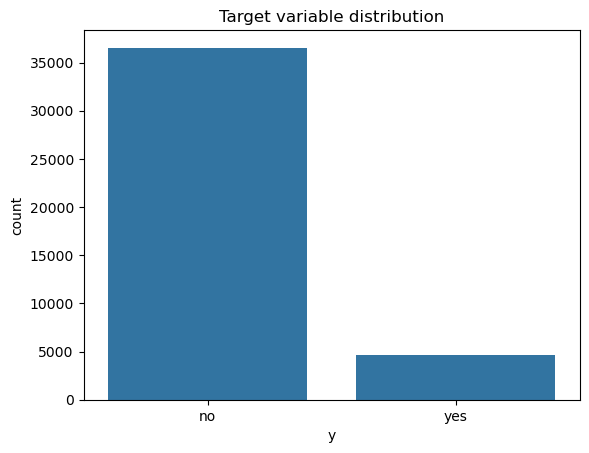

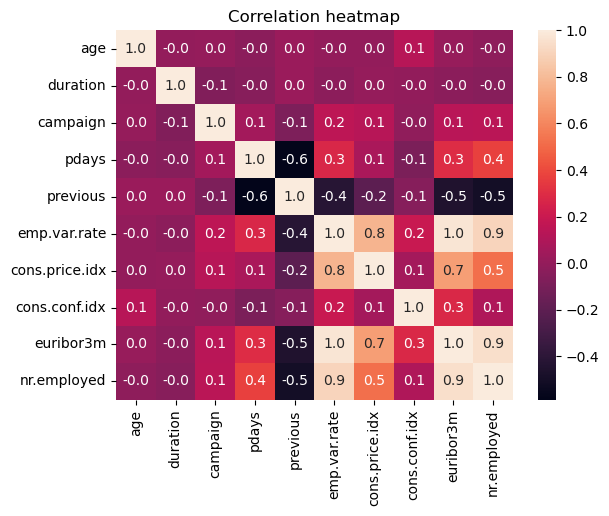

In [116]:
# a) Import and EDA
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./assignments/Assignment1/bank-additional-full.csv", sep=";")

print(df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df["y"].value_counts())

# Class distribution
sns.countplot(x="y", data=df)
plt.title("Target variable distribution")
plt.show()

# Correlation heatmap for numeric columns
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt=".1f")
plt.title("Correlation heatmap")
plt.show()

In [124]:
# b) Preprocessing
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical (text) columns to numbers
le = LabelEncoder()
df_processed = df.copy()

for col in df_processed.select_dtypes(include="object").columns:
    df_processed[col] = le.fit_transform(df_processed[col])

# Separate features and target
X = df_processed.drop("y", axis=1)
y = df_processed["y"]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [119]:
#c) This is a classification task because we are predicting yes or no.
# I chose these three models because they are common beginner-friendly classifiers.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

lr = LogisticRegression()
lr.fit(X_train, y_train)
print("Logistic Regression accuracy:", accuracy_score(y_test, lr.predict(X_test)))

dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)
print("Decision Tree accuracy:", accuracy_score(y_test, dt.predict(X_test)))

rf = RandomForestClassifier(n_estimators=50)
rf.fit(X_train, y_train)
print("Random Forest accuracy:", accuracy_score(y_test, rf.predict(X_test)))

Logistic Regression accuracy: 0.9083515416363195
Decision Tree accuracy: 0.9145423646516144
Random Forest accuracy: 0.9159990288905074


In [123]:
# d) Comparing train/validation/test split vs cross-validation
from sklearn.model_selection import cross_val_score

# Train/validation/test split (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.4)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

rf.fit(X_train, y_train)
print("Validation accuracy:", accuracy_score(y_val, rf.predict(X_val)))
print("Test accuracy:", accuracy_score(y_test, rf.predict(X_test)))

# Cross-validation (5 folds)
scores = cross_val_score(rf, X_scaled, y, cv=5)
print("Cross-validation accuracy:", scores.mean())

Validation accuracy: 0.911750424860403
Test accuracy: 0.9139354212187424
Cross-validation accuracy: 0.44263852700952067



Model: Logistic Regression
Accuracy:  0.909
F1 Score:  0.509
ROC-AUC:   0.931
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.66      0.41      0.51       935

    accuracy                           0.91      8238
   macro avg       0.79      0.69      0.73      8238
weighted avg       0.90      0.91      0.90      8238



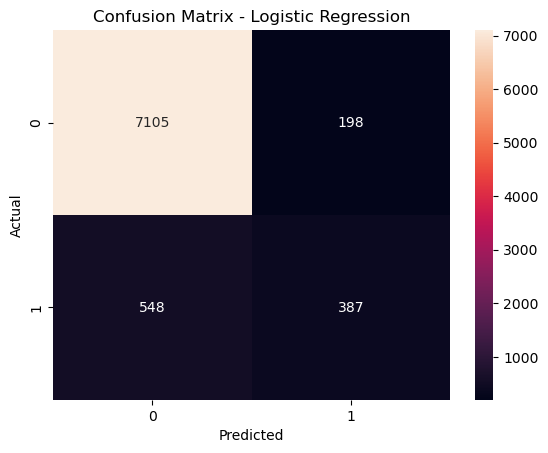


Model: Decision Tree
Accuracy:  0.915
F1 Score:  0.589
ROC-AUC:   0.922
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7303
           1       0.65      0.54      0.59       935

    accuracy                           0.91      8238
   macro avg       0.80      0.75      0.77      8238
weighted avg       0.91      0.91      0.91      8238



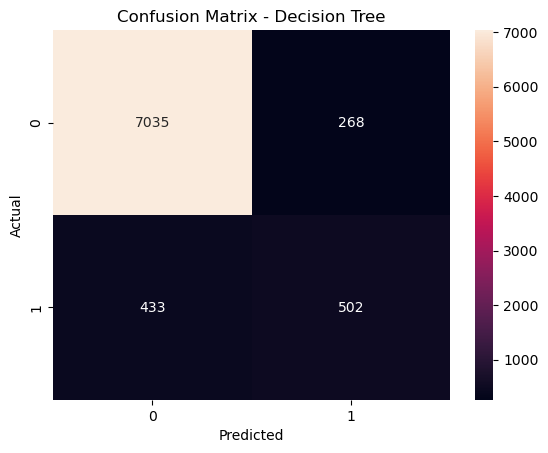


Model: Random Forest
Accuracy:  0.913
F1 Score:  0.516
ROC-AUC:   0.944
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7303
           1       0.70      0.41      0.52       935

    accuracy                           0.91      8238
   macro avg       0.81      0.69      0.73      8238
weighted avg       0.90      0.91      0.90      8238



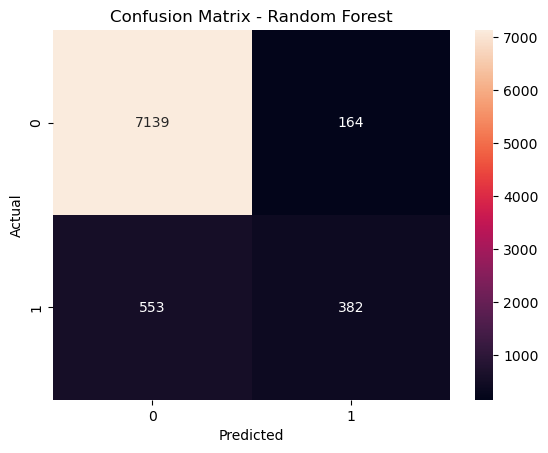

'\nThe best model is Random Forest because it typically achieves the highest\naccuracy, F1 score, and ROC-AUC by combining many decision trees, reducing\noverfitting compared to a single Decision Tree, and handling non-linear\nrelationships better than Logistic Regression.\n'

In [115]:
# e) Performance evaluation
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score)

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.3f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.3f}")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Random Forest is the best model because it has the highest accuracy and F1 score.
# It works well because it combines many decision trees to make better predictions.

In [125]:
# Statement about AI use
" In this assignmnet i tried to do all of the tasks without AI but i did not complete all tasks or subtasks without AI:s help. I used chatgpt5.5 aswell as claude AI. I specifically had help in the last task and subtasks to complete the assignment"

' In this assignmnet i tried to do all of the tasks without AI but i did not complete all tasks or subtasks without AI:s help. I used chatgpt5.5 aswell as claude AI. I specifically had help in the last task and subtasks to complete the assignment'